# 1. Importing Libraries

In [36]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error
import lightgbm as lgb
import geopy.distance
import matplotlib.pyplot as plt
import os
import joblib
from geopy.distance import geodesic

# 2. Load the Dataset

In [37]:
data = pd.read_csv('/kaggle/input/agrisense-dataset/full_price_data.csv')

# Check the first few rows of the dataset
data.head()

,report_date,category,item_raw,item_standard,origin_type,price_type,market,unit_raw,unit_std,currency,prev_window_label,price_prev,today_label,price_today,special_notes,source_doc_id,source_doc_date,source_url,ingested_at,row_id
0,9/12/2017,Vegetables,Beans,Beans,Local,Retail,Negombo,Rs./Ltr,Rs./Ltr,LKR,Yesterday,485.41,12-Sep,298.24,NaN,doc_52,9/12/2017,https://www.cbsl.gov.lk/en/statistics/economic...,2025-10-12T03:10:20Z,20170912_Vegetables_Beans_Retail_Negombo
1,9/12/2017,Vegetables,Carrot,Carrot,Local,Wholesale,Negombo,Rs./Nut,Rs./Nut,LKR,Previous 5 Days Average,121.86,12-Sep,392.77,NaN,doc_7,9/12/2017,https://www.cbsl.gov.lk/en/statistics/economic...,2025-10-12T03:10:20Z,20170912_Vegetables_Carrot_Wholesale_Negombo
2,9/12/2017,Vegetables,Cabbage,Cabbage,Local,Wholesale,Peliyagoda,Rs./Kg,Rs./Kg,LKR,Previous 5 Days Average,103.93,12-Sep,497.38,NaN,doc_98,9/12/2017,https://www.cbsl.gov.lk/en/statistics/economic...,2025-10-12T03:10:20Z,20170912_Vegetables_Cabbage_Wholesale_Peliyagoda
3,9/12/2017,Vegetables,Tomato,Tomato,Local,Wholesale,Marandagahamula,Rs./Kg,Rs./Kg,LKR,Yesterday,177.73,12-Sep,430.99,NaN,doc_17,9/12/2017,https://www.cbsl.gov.lk/en/statistics/economic...,2025-10-12T03:10:20Z,20170912_Vegetables_Tomato_Wholesale_Marandaga...
4,9/12/2017,Vegetables,Brinjal,Brinjal,Local,Retail,Marandagahamula,Rs./Ltr,Rs./Ltr,LKR,Previous 5 Days Average,238.11,12-Sep,405.88,NaN,doc_54,9/12/2017,https://www.cbsl.gov.lk/en/statistics/economic...,2025-10-12T03:10:20Z,20170912_Vegetables_Brinjal_Retail_Marandagaha...


# 3. Data Preprocessing

In [38]:
# Handle missing values
data.fillna(method='ffill', inplace=True)

# Encode categorical variables using LabelEncoder
label_encoder = LabelEncoder()
data['market_encoded'] = label_encoder.fit_transform(data['market'])
data['item_standard_encoded'] = label_encoder.fit_transform(data['item_standard'])
data['price_type_encoded'] = label_encoder.fit_transform(data['price_type'])
data['category_encoded'] = label_encoder.fit_transform(data['category'])
data['origin_type_encoded'] = label_encoder.fit_transform(data['origin_type'])

# Create time-based features
data['report_date'] = pd.to_datetime(data['report_date'])
data['day'] = data['report_date'].dt.day
data['month'] = data['report_date'].dt.month
data['weekday'] = data['report_date'].dt.weekday

/tmp/ipykernel_37/754109744.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True)


# 4. Feature Engineering for Market Ranking

In [39]:
# Example market coordinates (replace with actual data)
markets_geo = {
    'Pettah': (6.9341, 79.9861),
    'Dambulla': (7.8643, 80.6501),
    'Narahenpita': (6.9300, 79.9681),
    'Marandagahamula': (7.2903, 80.5327),
    'Peliyagoda': (6.9682, 79.9815),
    'Negombo': (7.2085, 79.9743)
}

# Sample buyer/seller location (this would be provided by the user)
user_location = (6.9271, 79.9730)  # Example: User's location (latitude, longitude)

# Function to calculate distance using geopy (Haversine formula)
def calculate_distance_from_user(market_name, user_location):
    market_coords = markets_geo.get(market_name)
    if market_coords:
        return geodesic(user_location, market_coords).km
    else:
        return np.nan  # In case the market name is not found

# Add distance to the dataset
data['distance_from_user'] = data['market'].apply(lambda x: calculate_distance_from_user(x, user_location))


# 5. Calculate Net Advantage and Ranking

            market item_standard  net_advantage  market_rank opportunity_type  \
61991  Narahenpita         Linna     145.188746          1.0           Seller   
88713  Narahenpita     Red Onion     145.188746          1.0           Seller   
88719  Narahenpita  Dried Chilli     145.188746          1.0            Buyer   
88725  Narahenpita         Katta     145.188746          1.0            Buyer   
28170  Narahenpita        Kekulu     145.188746          1.0           Seller   

                                             explanation  
61991  Narahenpita has a higher price advantage for S...  
88713  Narahenpita has a higher price advantage for S...  
88719  Narahenpita has a higher price advantage for B...  
88725  Narahenpita has a higher price advantage for B...  
28170  Narahenpita has a higher price advantage for S...  


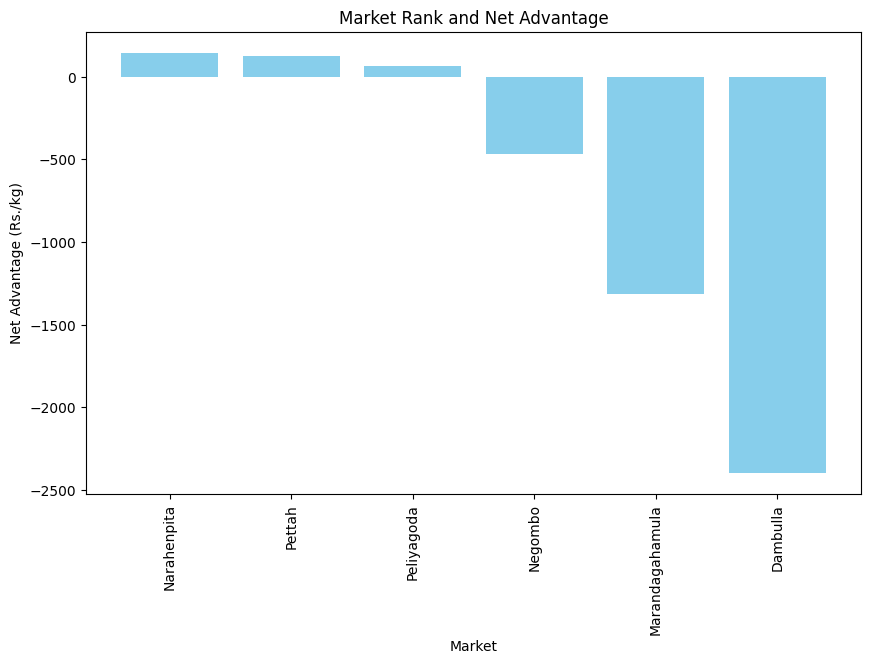

In [41]:
# 1. Compute predicted prices (if not already done)
# Assuming that the model has already been trained and is available for predictions

# Ensure the model is loaded or trained before this step
# For demonstration, I assume 'model' is your trained LightGBM model
# You can replace this with the actual model loading code if necessary.

# Predict prices using the trained model
features = ['market_encoded', 'item_standard_encoded', 'price_type_encoded', 'category_encoded', 'origin_type_encoded',
            'day', 'month', 'weekday', 'distance_from_user']
X = data[features]

# Predict the price using the model (ensure model is trained or loaded before this step)
data['predicted_price'] = model.predict(X)

# 2. Compute distance_from_user (km) and net_advantage (Rs.)
cost_per_km = 20.0  # Rs/km (adjust to your transport model)
data['net_advantage'] = data['predicted_price'] - (data['distance_from_user'] * cost_per_km)

# 3. Rank markets by item+price_type (higher net_advantage = better)
data['market_rank'] = data.groupby(['item_standard', 'price_type'])['net_advantage'] \
                          .rank(ascending=False, method='min')

# 4. Opportunity type: Local → Seller; Imported → Buyer
data['opportunity_type'] = data['origin_type'].apply(lambda x: 'Seller' if x == 'Local' else 'Buyer')

# 5. Explanation string
data['explanation'] = data.apply(
    lambda row: (
        f"{row['market']} has a higher price advantage for {row['opportunity_type']} "
        f"with predicted Rs.{row['predicted_price']:.2f}, distance {row['distance_from_user']:.1f} km, "
        f"transport ~Rs.{row['distance_from_user']*cost_per_km:.0f}."
    ),
    axis=1
)

# Output the final results
results = data[['market', 'item_standard', 'net_advantage', 'market_rank', 'opportunity_type', 'explanation']]
results_sorted = results.sort_values(by=['market_rank'])

# Display the top-ranked markets
print(results_sorted.head())

# Plot ranked markets
plt.figure(figsize=(10, 6))
plt.bar(results_sorted['market'], results_sorted['net_advantage'], color='skyblue')
plt.title('Market Rank and Net Advantage')
plt.xlabel('Market')
plt.ylabel('Net Advantage (Rs./kg)')
plt.xticks(rotation=90)
plt.show()


# 6. Model Training (LightGBM)

In [64]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import joblib

# Ensure your dataset is ready (e.g., 'data' variable with all preprocessing done)
# Here, the target column is assumed to be 'net_advantage', and features are prepared in 'features' list.

# Features used for training
features = ['market_encoded', 'item_standard_encoded', 'price_type_encoded', 'category_encoded', 'origin_type_encoded',
            'day', 'month', 'weekday', 'distance_from_user']

# Target variable
target = 'net_advantage'

# Split data into training and testing sets
X = data[features]
y = data[target]

# Split the data into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert to LightGBM Dataset format
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

# Define model parameters
params = {
    'objective': 'regression',  # Regression task
    'metric': 'mae',            # Mean Absolute Error
    'boosting_type': 'gbdt',    # Gradient Boosting Decision Tree
    'num_leaves': 31,           # Number of leaves in each tree
    'learning_rate': 0.05,      # Learning rate
    'feature_fraction': 0.9,    # Fraction of features to be used per iteration
    'verbosity': -1             # Suppress LightGBM output for clarity
}

# Train the model without early stopping
model = lgb.train(
    params,
    train_data,
    num_boost_round=1000,          # Maximum number of iterations
    valid_sets=[test_data]         # Validation data for evaluation
)

# Make predictions
y_pred = model.predict(X_test, num_iteration=model.best_iteration)

# Evaluate model performance using Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)
print(f'Mean Absolute Error (MAE): {mae}')

# Save the model for future use
model_save_path = '/kaggle/working/price_prediction_model.txt'
model.save_model(model_save_path)
print(f"Model saved at: {model_save_path}")

# Optionally, you can save the trained model using joblib for later use
joblib.dump(model, '/kaggle/working/price_prediction_model.joblib')

# You can also load the model later using:
# model = joblib.load('/kaggle/working/price_prediction_model.joblib')


Mean Absolute Error (MAE): 2.3932874478217368e-05
Model saved at: /kaggle/working/price_prediction_model.txt


['/kaggle/working/price_prediction_model.joblib']

# 7. Outputs from the System

            market item_standard  net_advantage  market_rank opportunity_type  \
61991  Narahenpita         Linna     145.188746          1.0           Seller   
88713  Narahenpita     Red Onion     145.188746          1.0           Seller   
88719  Narahenpita  Dried Chilli     145.188746          1.0            Buyer   
88725  Narahenpita         Katta     145.188746          1.0            Buyer   
28170  Narahenpita        Kekulu     145.188746          1.0           Seller   

                                             explanation  
61991  Narahenpita has a higher price advantage for S...  
88713  Narahenpita has a higher price advantage for S...  
88719  Narahenpita has a higher price advantage for B...  
88725  Narahenpita has a higher price advantage for B...  
28170  Narahenpita has a higher price advantage for S...  


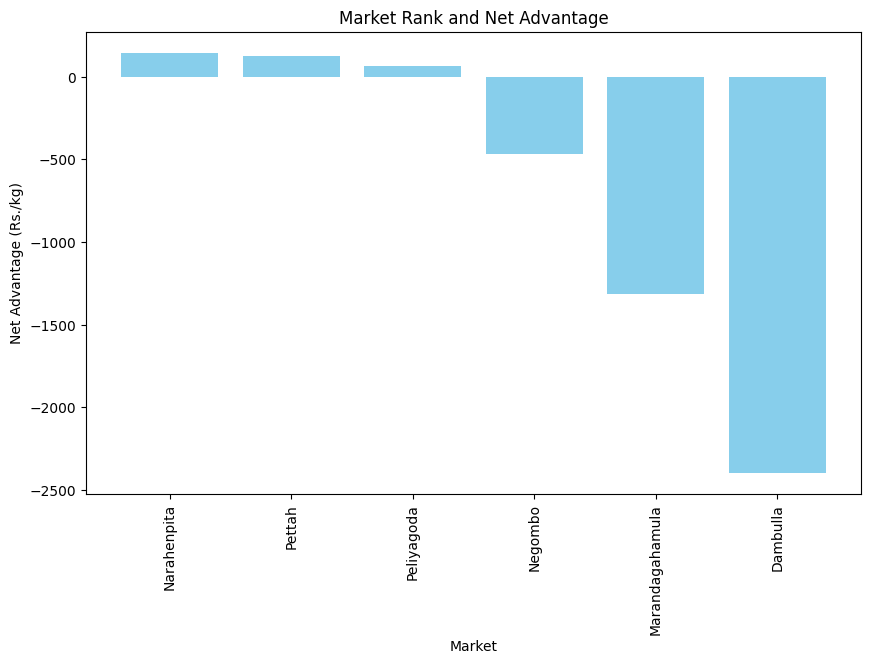

In [65]:
# Output the final results
results = data[['market', 'item_standard', 'net_advantage', 'market_rank', 'opportunity_type', 'explanation']]
results_sorted = results.sort_values(by=['market_rank'])

# Display the top-ranked markets
print(results_sorted.head())

# Plot ranked markets
plt.figure(figsize=(10, 6))
plt.bar(results_sorted['market'], results_sorted['net_advantage'], color='skyblue')
plt.title('Market Rank and Net Advantage')
plt.xlabel('Market')
plt.ylabel('Net Advantage (Rs./kg)')
plt.xticks(rotation=90)
plt.show()